# Session 07 - Classification Models

This notebook trains binary and multiclass classifiers, inspects predicted probabilities, evaluates confusion matrices and tunes a decision threshold.

**Classroom rule:** classification output is a decision support signal, not an automatic decision. Always connect metrics to the cost of false positives and false negatives.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score, recall_score,
    f1_score, accuracy_score, roc_auc_score
)

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 7
DATA_PATH = Path('workplace_service_classification_dataset.csv')


## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
print('\nBinary target balance:')
print(df['sla_breach'].value_counts(normalize=True).rename('proportion'))
print('\nMulticlass target balance:')
print(df['priority_class'].value_counts(normalize=True).rename('proportion'))


Shape: (900, 18)


,request_id,customer_segment,service_area,channel,region,request_type,urgency_score,previous_cases_90d,account_age_months,open_cases_at_submission,avg_response_minutes_30d,sentiment_score_at_submission,missing_documents_flag,weekend_submission,priority_class,sla_breach,resolution_days_post_outcome,post_resolution_status
0,REQ-00001,Individual,HR services,Email,South East,Billing query,3,2,34,1,26.4,0.950,1,1,Standard,1,7.6,Late - complex
1,REQ-00002,Enterprise,IT support,Email,Wales,Access issue,1,2,3,1,83.6,0.411,0,0,Low,0,4.2,Early close
2,REQ-00003,Individual,IT support,Portal,Scotland,Technical incident,4,2,36,0,52.3,-0.287,0,0,Urgent,1,5.8,Late - dependency
3,REQ-00004,Public sector,HR services,Email,Midlands,Billing query,3,1,16,1,57.6,-0.580,0,0,Low,1,6.0,Late - dependency
4,REQ-00005,SME,Customer success,Email,South East,Complaint,4,0,65,0,50.1,0.305,0,0,Standard,1,7.5,Late - staffing



Binary target balance:
sla_breach
1    0.705556
0    0.294444
Name: proportion, dtype: float64

Multiclass target balance:
priority_class
Standard    0.373333
Urgent      0.348889
Low         0.277778
Name: proportion, dtype: float64


## 2. Choose safe features

Exclude IDs, target columns and post-outcome/leaky fields. In real projects, confirm feature timing with the process owner.

In [3]:
numeric_features = [
    'urgency_score', 'previous_cases_90d', 'account_age_months',
    'open_cases_at_submission', 'avg_response_minutes_30d',
    'sentiment_score_at_submission', 'missing_documents_flag', 'weekend_submission'
]

categorical_features = [
    'customer_segment', 'service_area', 'channel', 'region', 'request_type'
]

leaky_or_excluded = [
    'request_id', 'priority_class', 'sla_breach',
    'resolution_days_post_outcome', 'post_resolution_status'
]

X = df[numeric_features + categorical_features]
y_binary = df['sla_breach']
y_multi = df['priority_class']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


## 3. Binary classification: SLA breach vs no breach

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.25, stratify=y_binary, random_state=RANDOM_STATE
)

models = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision tree': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight='balanced'),
    'Random forest': RandomForestClassifier(n_estimators=150, max_depth=7, random_state=RANDOM_STATE, class_weight='balanced')
}

binary_results = []
fitted_binary = {}
for name, clf in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted_binary[name] = pipe
    row = {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0)
    }
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        prob = pipe.predict_proba(X_test)[:, 1]
        row['roc_auc'] = roc_auc_score(y_test, prob)
    binary_results.append(row)

results_df = pd.DataFrame(binary_results).sort_values('f1', ascending=False)
display(results_df)


,model,accuracy,precision,recall,f1,roc_auc
0,Dummy baseline,0.706667,0.706667,1.000000,0.828125,0.500000
3,Random forest,0.675556,0.747126,0.817610,0.780781,0.644082
1,Logistic regression,0.657778,0.810606,0.672956,0.735395,0.715933
2,Decision tree,0.626667,0.790698,0.641509,0.708333,0.602582


## 4. Confusion matrix and probability inspection

              precision    recall  f1-score   support

   No breach       0.44      0.62      0.52        66
  SLA breach       0.81      0.67      0.74       159

    accuracy                           0.66       225
   macro avg       0.63      0.65      0.63       225
weighted avg       0.70      0.66      0.67       225



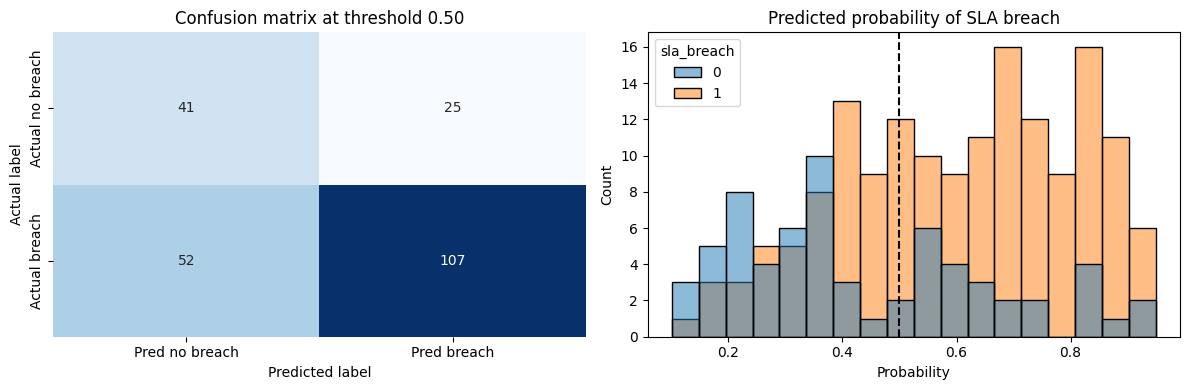

In [5]:
selected_model_name = 'Logistic regression'
selected_model = fitted_binary[selected_model_name]
y_pred = selected_model.predict(X_test)
y_prob = selected_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=['No breach', 'SLA breach']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred no breach','Pred breach'],
            yticklabels=['Actual no breach','Actual breach'], ax=axes[0])
axes[0].set_title('Confusion matrix at threshold 0.50')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

sns.histplot(x=y_prob, hue=y_test, bins=18, stat='count', common_norm=False, ax=axes[1])
axes[1].axvline(0.5, color='black', linestyle='--')
axes[1].set_title('Predicted probability of SLA breach')
axes[1].set_xlabel('Probability')
plt.tight_layout()
plt.show()


## 5. Threshold tuning

The default threshold is 0.50. Lowering the threshold usually increases recall but can create more false positives. Raising the threshold usually increases precision but can miss more true breach cases.

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,0.2,0.727700,0.974843,0.833333,58,4,155,8
1,0.3,0.768421,0.918239,0.836676,44,13,146,22
2,0.4,0.826087,0.836478,0.831250,28,26,133,38
3,0.5,0.810606,0.672956,0.735395,25,52,107,41
4,0.6,0.838384,0.522013,0.643411,16,76,83,50
5,0.7,0.865672,0.364780,0.513274,9,101,58,57
6,0.8,0.833333,0.220126,0.348259,7,124,35,59


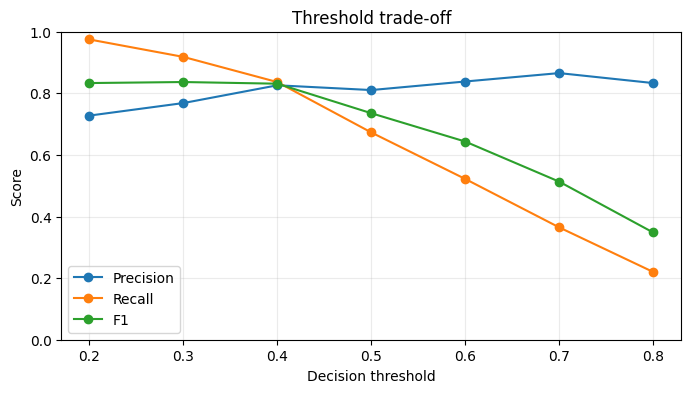

In [6]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
rows = []
for threshold in thresholds:
    threshold_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    rows.append({
        'threshold': threshold,
        'precision': precision_score(y_test, threshold_pred, zero_division=0),
        'recall': recall_score(y_test, threshold_pred, zero_division=0),
        'f1': f1_score(y_test, threshold_pred, zero_division=0),
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'true_negatives': tn
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

plt.figure(figsize=(8, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Threshold trade-off')
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 6. Multiclass classification: priority class

In [7]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.25, stratify=y_multi, random_state=RANDOM_STATE
)

multi_models = {
    'Logistic regression multiclass': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random forest multiclass': RandomForestClassifier(n_estimators=150, max_depth=8, random_state=RANDOM_STATE, class_weight='balanced')
}

multi_fitted = {}
for name, clf in multi_models.items():
    pipe = Pipeline([('preprocess', preprocess), ('classifier', clf)])
    pipe.fit(X_train_m, y_train_m)
    pred = pipe.predict(X_test_m)
    multi_fitted[name] = pipe
    print('\n' + '='*80 + '\n' + name)
    print(classification_report(y_test_m, pred))



Logistic regression multiclass
              precision    recall  f1-score   support

         Low       0.73      0.78      0.75        63
    Standard       0.62      0.57      0.60        84
      Urgent       0.78      0.81      0.79        78

    accuracy                           0.71       225
   macro avg       0.71      0.72      0.71       225
weighted avg       0.71      0.71      0.71       225




Random forest multiclass
              precision    recall  f1-score   support

         Low       0.78      0.78      0.78        63
    Standard       0.64      0.60      0.62        84
      Urgent       0.75      0.81      0.78        78

    accuracy                           0.72       225
   macro avg       0.72      0.73      0.72       225
weighted avg       0.72      0.72      0.72       225



## 7. Multiclass confusion matrix

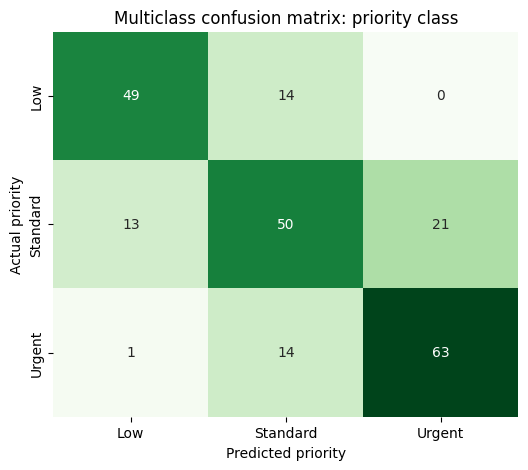

In [8]:
multi_model = multi_fitted['Random forest multiclass']
y_pred_m = multi_model.predict(X_test_m)
labels = ['Low', 'Standard', 'Urgent']
cm_m = confusion_matrix(y_test_m, y_pred_m, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.title('Multiclass confusion matrix: priority class')
plt.xlabel('Predicted priority')
plt.ylabel('Actual priority')
plt.show()


## 8. Student reflection

Answer in markdown below:

1. Which model would you present first to a business stakeholder and why?
2. Which error is more costly for SLA breach: false positive or false negative?
3. Which threshold would you choose and why?
4. What fairness or deployment caveat should be checked before using this classifier?